### post_generation_flow (iterative example)
![post_generation_flow (iterative example)](images_md/post_generation_flow.png)

In [22]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage
from typing import TypedDict, Literal, Annotated
from langchain_openrouter import ChatOpenRouter
from dotenv import load_dotenv
from pydantic import BaseModel, Field


In [23]:
load_dotenv()

True

In [ ]:
generator_llm = ChatOpenRouter(
    model="openrouter/free",
    temperature=0.6
)

evaluator_llm = ChatOpenRouter(
    model="openrouter/free",
    temperature=0.6
)

optimizer_llm = ChatOpenRouter(
    model="openrouter/free",
    temperature=0.6
)


In [25]:
prompt = f'How are you today ?'

answer = generator_llm.invoke(prompt).content

print('generator_llm answer ', answer)

answer = evaluator_llm.invoke(prompt).content

print('evaluator_llm answer ', answer)

answer = optimizer_llm.invoke(prompt).content

print('optimizer_llm answer ', answer)


generator_llm answer  I’m doing great—thanks for asking! How about you? Anything interesting on your end today?


TooManyRequestsResponseError: Provider returned error

In [5]:
### Define State

class TweetState(TypedDict):
    topic : str
    tweet : str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iterations: int
    


In [6]:
class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation")
    feedback: str = Field(..., description="constructive feedback")


In [7]:
structure_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [8]:
def generate_post(state:TweetState):

    # call llm with prompt to generate post
    messages = [
        SystemMessage(content=f"""
You are a professional social media copywriter who creates engaging tweets for X (formerly Twitter).

Your task is to generate ONE tweet based on the user-provided topic.

Rules:
- The tweet must be concise, engaging, and under 280 characters.
- Start with a strong hook or interesting statement.
- Make it sound natural and human, not robotic or overly promotional.
- Use simple, clear language.
- Include 1-3 relevant hashtags only if they add value.
- Do not use quotation marks around the tweet.
- Do not include explanations, labels, or multiple options.
- Do not mention that you are an AI.
- Avoid clickbait, misinformation, and excessive emojis (maximum 1 emoji).
- Return ONLY the final tweet text.
- This is version {state['iteration'] + 1}

Goal:
Create a tweet that is likely to get attention, likes, reposts, and replies while staying relevant to the given topic.

"""),
HumanMessage(content=f"""Write a tweet on the topic {state['topic']}""")
    
    ]

    # send generator_llm
    responce = generator_llm.invoke(messages).content

    # return tweet
    return {'tweet' : responce}



In [9]:
def evaluate_post(state:TweetState):

    messages = [
    SystemMessage(content=f"""
You are an expert social media evaluator for X (formerly Twitter).

Your task is to evaluate the generated tweet based on the given topic and provide a quality score and feedback.

Evaluation criteria:
- Relevance to the topic
- Clarity and readability
- Engagement potential (likes, reposts, replies)
- Conciseness (must be under 280 characters)
- Natural and human-like tone
- Proper use of hashtags (0-3, only if relevant)
- No misleading, spammy, or clickbait content
- No unnecessary emojis (maximum 1)


Return ONLY valid JSON in the following format:
{{
  "evaluation": "approved" or "needs_improvement",
  "feedback": "One paragraph explaning the strengths and weakness",
}}

Rules:
- Do not include markdown or code fences.
- Do not include any extra text before or after the JSON.
- Keep feedback concise (1-2 sentences).
- This is evaluation round {state['iteration'] + 1}.
"""),

    HumanMessage(content=f"""
Topic: {state['topic']}

Tweet:
{state['tweet']}

Evaluate this tweet and return the JSON response.
""")
]
    
    response = structure_evaluator_llm.invoke(messages)
    
    return {'evaluation': response.evaluation, 'feedback' : response.feedback}



In [10]:
def optimize_post(state:TweetState):

    messages = [
    SystemMessage(content=f"""
You are an expert social media copywriter and tweet optimizer for X (formerly Twitter).

Your task is to improve the provided tweet using the evaluator's feedback and suggestions.

Rules:
- Keep the tweet under 280 characters.
- Preserve the original intent and topic.
- Improve clarity, engagement, and readability.
- Start with a stronger hook if possible.
- Make the tone natural and human-like.
- Use simple, impactful language.
- Include 0-3 relevant hashtags only if they add value.
- Do not use quotation marks around the tweet.
- Do not include explanations, labels, or multiple versions.
- Do not mention the evaluator, feedback, or that you are an AI.
- Avoid clickbait, misinformation, and excessive emojis (maximum 1).
- Return ONLY the improved tweet text.
- This is optimization round {state['iteration'] + 1}.

Goal:
Produce a revised tweet that addresses the evaluator's concerns and is more likely to achieve a higher engagement score and pass the evaluation.
"""),

    HumanMessage(content=f"""
Topic: {state['topic']}

Original tweet:
{state['tweet']}

Evaluator feedback:
{state['feedback']}


Rewrite the tweet so it is more engaging and better aligned with the feedback.
""")
]
    
    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration}

In [11]:
def route_evaluation(state: TweetState):
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iterations']:
        return 'approved'
    else:
        return 'needs_improvements'

In [12]:
# define graph
post_graph = StateGraph(TweetState)

# add nodes
post_graph.add_node('generate_post', generate_post)
post_graph.add_node('evaluate_post', evaluate_post)
post_graph.add_node('optimize_post', optimize_post)

# connect edges
post_graph.add_edge(START, 'generate_post')
post_graph.add_edge('generate_post', 'evaluate_post')

post_graph.add_conditional_edges('evaluate_post', route_evaluation, {'approved': END, 'needs_improvement':'optimize_post'})

post_graph.add_edge('optimize_post', 'evaluate_post')

# compile graph
post_flow = post_graph.compile()

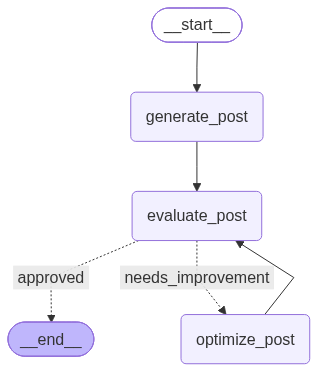

In [13]:
post_flow

In [14]:
start_state = {
    "topic" : "Indian Festivals",
    "iteration": 1,
    "max_iterations":1

}

res = post_flow.invoke(start_state)

In [26]:
print(res)

{'topic': 'Indian Festivals', 'tweet': "From Diwali lights to Holi colors, India's festivals paint life in vibrant hues. Which celebration lights up your heart? #IndianFestivals", 'evaluation': 'approved', 'feedback': 'The tweet is relevant, clear, engaging with a question prompt, concise, and uses one appropriate hashtag with a natural tone and no spam or excessive emojis.', 'iteration': 1, 'max_iterations': 1}


In [21]:
print(res['tweet'])

From Diwali lights to Holi colors, India's festivals paint life in vibrant hues. Which celebration lights up your heart? #IndianFestivals
